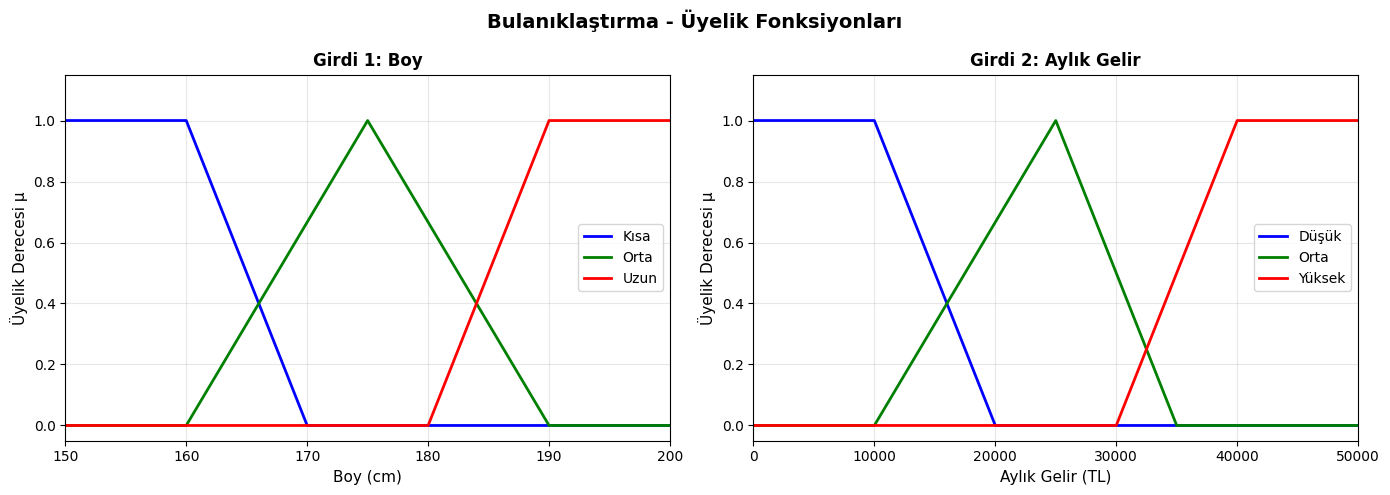

In [15]:
#FONKSİYONLAR VE GRAFİKLERi

import numpy as np
import matplotlib.pyplot as plt


# ÜYELİK FONKSİYONLARI - BOY
# Yamuk fonksiyon: 150-160 tam üye (1.0), 160-170 arası düşüş

def kisa_boy(x):
    if x <= 160: return 1.0               # 160 cm ve altı tamamen kısa
    elif x <= 170: return (170 - x) / 10  # 160-170 arası doğrusal azalış
    else: return 0.0                       # 170 cm üstü kısa değil

# Üçgen fonksiyon: 160'ta başlar, 175'te zirve, 190'da biter
def orta_boy(x):
    if x <= 160: return 0.0               # 160 cm altı orta değil
    elif x <= 175: return (x - 160) / 15  # 160-175 arası doğrusal artış
    elif x <= 190: return (190 - x) / 15  # 175-190 arası doğrusal azalış
    else: return 0.0                       # 190 cm üstü orta değil

# Yamuk fonksiyon: 180-190 arası yükseliş, 190 üstü tam üye (1.0)
def uzun_boy(x):
    if x <= 180: return 0.0               # 180 cm altı uzun değil
    elif x <= 190: return (x - 180) / 10  # 180-190 arası doğrusal artış
    else: return 1.0                       # 190 cm ve üstü tamamen uzun


# ÜYELİK FONKSİYONLARI - GELİR
# Yamuk fonksiyon: 0-10000 tam üye (1.0), 10000-20000 arası düşüş

def dusuk_gelir(x):
    if x <= 10000: return 1.0                       # 10.000 TL altı tamamen düşük
    elif x <= 20000: return (20000 - x) / 10000     # 10k-20k arası doğrusal azalış
    else: return 0.0                                 # 20.000 TL üstü düşük değil

# Üçgen fonksiyon: 10k'da başlar, 25k'da zirve, 35k'da biter
def orta_gelir(x):
    if x <= 10000: return 0.0                       # 10.000 TL altı orta değil
    elif x <= 25000: return (x - 10000) / 15000     # 10k-25k arası doğrusal artış
    elif x <= 35000: return (35000 - x) / 10000     # 25k-35k arası doğrusal azalış
    else: return 0.0                                 # 35.000 TL üstü orta değil

# Yamuk fonksiyon: 30k-40k arası yükseliş, 40k üstü tam üye (1.0)
def yuksek_gelir(x):
    if x <= 30000: return 0.0                       # 30.000 TL altı yüksek değil
    elif x <= 40000: return (x - 30000) / 10000     # 30k-40k arası doğrusal artış
    else: return 1.0                                 # 40.000 TL üstü tamamen yüksek


# GRAFİKLERİ ÇİZME KISMI

boy_aralik   = np.arange(150, 201, 1)
gelir_aralik = np.arange(0, 50001, 100)

mu_kisa  = [kisa_boy(x)   for x in boy_aralik]
mu_orta  = [orta_boy(x)   for x in boy_aralik]
mu_uzun  = [uzun_boy(x)   for x in boy_aralik]

mu_dusuk  = [dusuk_gelir(x)  for x in gelir_aralik]
mu_orta_g = [orta_gelir(x)   for x in gelir_aralik]
mu_yuksek = [yuksek_gelir(x) for x in gelir_aralik]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bulanıklaştırma - Üyelik Fonksiyonları", fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(boy_aralik, mu_kisa, 'b-', linewidth=2, label='Kısa')
ax1.plot(boy_aralik, mu_orta, 'g-', linewidth=2, label='Orta')
ax1.plot(boy_aralik, mu_uzun, 'r-', linewidth=2, label='Uzun')
ax1.set_xlabel('Boy (cm)', fontsize=11)
ax1.set_ylabel('Üyelik Derecesi μ', fontsize=11)
ax1.set_title('Girdi 1: Boy', fontsize=12, fontweight='bold')
ax1.set_ylim(-0.05, 1.15)
ax1.set_xlim(150, 200)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(gelir_aralik, mu_dusuk,  'b-', linewidth=2, label='Düşük')
ax2.plot(gelir_aralik, mu_orta_g, 'g-', linewidth=2, label='Orta')
ax2.plot(gelir_aralik, mu_yuksek, 'r-', linewidth=2, label='Yüksek')
ax2.set_xlabel('Aylık Gelir (TL)', fontsize=11)
ax2.set_ylabel('Üyelik Derecesi μ', fontsize=11)
ax2.set_title('Girdi 2: Aylık Gelir', fontsize=12, fontweight='bold')
ax2.set_ylim(-0.05, 1.15)
ax2.set_xlim(0, 50000)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# KULLANICIDAN GİRİŞ ALMA KISMI


# Kullanıcıdan giriş alma
boy_giris   = float(input("Boy değerini giriniz (cm) [150-200]: "))
gelir_giris = float(input("Aylık gelir giriniz (TL) [0-50000]: "))


# BULANIKLAŞTIRMA - BOY
# Her üyelik fonksiyonu çağrılır ve sonuç 0-1 arasında üyelik derecesi döner

b_kisa = kisa_boy(boy_giris)   # Girilen boy "kısa" kümesine ne kadar üye?
b_orta = orta_boy(boy_giris)   # Girilen boy "orta" kümesine ne kadar üye?
b_uzun = uzun_boy(boy_giris)   # Girilen boy "uzun" kümesine ne kadar üye?


# BULANIKLAŞTIRMA - GELİR

g_dusuk  = dusuk_gelir(gelir_giris)   # Girilen gelir "düşük"  kümesine ne kadar üye?
g_orta   = orta_gelir(gelir_giris)    # Girilen gelir "orta"   kümesine ne kadar üye?
g_yuksek = yuksek_gelir(gelir_giris)  # Girilen gelir "yüksek" kümesine ne kadar üye?

# SONUÇLARI SÖZLÜĞE ATMA - ilerleyen aşamalarda kolaylık olması için tercih ettim hocam.
# İleride kural tablosu ve çıkarım aşamasında bu sözlükler kullanılacak
# Erişim örneği: bulanik_boy["orta"] --> 0.8

bulanik_boy = {
    "kisa": b_kisa,   # "kısa" kümesindeki üyelik derecesi
    "orta": b_orta,   # "orta" kümesindeki üyelik derecesi
    "uzun": b_uzun    # "uzun" kümesindeki üyelik derecesi
}

bulanik_gelir = {
    "dusuk":  g_dusuk,   # "düşük"  kümesindeki üyelik derecesi
    "orta":   g_orta,    # "orta"   kümesindeki üyelik derecesi
    "yuksek": g_yuksek   # "yüksek" kümesindeki üyelik derecesi
}

# Sonuçları yazdırma kısmı
print("\n" + "="*45)
print(f"  BOY GİRİŞİ: {boy_giris} cm")
print("="*45)
for kume, derece in bulanik_boy.items():
    print(f"  {kume.capitalize():<8} üyelik derecesi: {derece:.4f}")

print("\n" + "="*45)
print(f"  GELİR GİRİŞİ: {gelir_giris:,.0f} TL")
print("="*45)
for kume, derece in bulanik_gelir.items():
    print(f"  {kume.capitalize():<8} üyelik derecesi: {derece:.4f}")

print("\n--- Sözlük içerikleri ---")
print(f"bulanik_boy   = {bulanik_boy}")
print(f"bulanik_gelir = {bulanik_gelir}")

Boy değerini giriniz (cm) [150-200]: 170
Aylık gelir giriniz (TL) [0-50000]: 26789

  BOY GİRİŞİ: 170.0 cm
  Kisa     üyelik derecesi: 0.0000
  Orta     üyelik derecesi: 0.6667
  Uzun     üyelik derecesi: 0.0000

  GELİR GİRİŞİ: 26,789 TL
  Dusuk    üyelik derecesi: 0.0000
  Orta     üyelik derecesi: 0.8211
  Yuksek   üyelik derecesi: 0.0000

--- Sözlük içerikleri ---
bulanik_boy   = {'kisa': 0.0, 'orta': 0.6666666666666666, 'uzun': 0.0}
bulanik_gelir = {'dusuk': 0.0, 'orta': 0.8211, 'yuksek': 0.0}


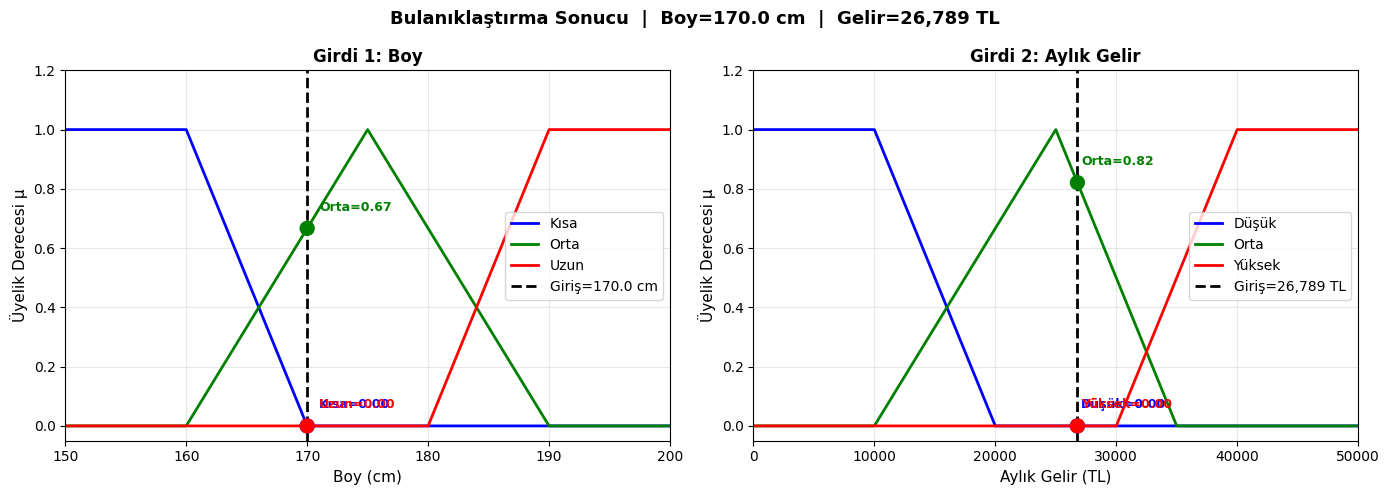

In [18]:
# GİRİLEN DEĞERLERİ GRAFİKTE GÖSTERME KISMI

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Bulanıklaştırma Sonucu  |  Boy={boy_giris} cm  |  Gelir={gelir_giris:,.0f} TL",
             fontsize=13, fontweight='bold')

# --- Boy grafiği ---
ax1 = axes[0]
ax1.plot(boy_aralik, mu_kisa, 'b-', linewidth=2, label='Kısa')
ax1.plot(boy_aralik, mu_orta, 'g-', linewidth=2, label='Orta')
ax1.plot(boy_aralik, mu_uzun, 'r-', linewidth=2, label='Uzun')
ax1.axvline(x=boy_giris, color='black', linestyle='--', linewidth=2, label=f'Giriş={boy_giris} cm')
ax1.scatter([boy_giris]*3, [b_kisa, b_orta, b_uzun], color=['blue','green','red'], s=100, zorder=5)
ax1.annotate(f'Kısa={b_kisa:.2f}', xy=(boy_giris, b_kisa), xytext=(boy_giris+1, b_kisa+0.06),
             fontsize=9, color='blue', fontweight='bold')
ax1.annotate(f'Orta={b_orta:.2f}', xy=(boy_giris, b_orta), xytext=(boy_giris+1, b_orta+0.06),
             fontsize=9, color='green', fontweight='bold')
ax1.annotate(f'Uzun={b_uzun:.2f}', xy=(boy_giris, b_uzun), xytext=(boy_giris+1, b_uzun+0.06),
             fontsize=9, color='red', fontweight='bold')
ax1.set_xlabel('Boy (cm)', fontsize=11)
ax1.set_ylabel('Üyelik Derecesi μ', fontsize=11)
ax1.set_title('Girdi 1: Boy', fontsize=12, fontweight='bold')
ax1.set_ylim(-0.05, 1.2)
ax1.set_xlim(150, 200)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Gelir grafiği ---
ax2 = axes[1]
ax2.plot(gelir_aralik, mu_dusuk,  'b-', linewidth=2, label='Düşük')
ax2.plot(gelir_aralik, mu_orta_g, 'g-', linewidth=2, label='Orta')
ax2.plot(gelir_aralik, mu_yuksek, 'r-', linewidth=2, label='Yüksek')
ax2.axvline(x=gelir_giris, color='black', linestyle='--', linewidth=2, label=f'Giriş={gelir_giris:,.0f} TL')
ax2.scatter([gelir_giris]*3, [g_dusuk, g_orta, g_yuksek], color=['blue','green','red'], s=100, zorder=5)
ax2.annotate(f'Düşük={g_dusuk:.2f}',  xy=(gelir_giris, g_dusuk),  xytext=(gelir_giris+300, g_dusuk+0.06),
             fontsize=9, color='blue', fontweight='bold')
ax2.annotate(f'Orta={g_orta:.2f}',    xy=(gelir_giris, g_orta),   xytext=(gelir_giris+300, g_orta+0.06),
             fontsize=9, color='green', fontweight='bold')
ax2.annotate(f'Yüksek={g_yuksek:.2f}',xy=(gelir_giris, g_yuksek), xytext=(gelir_giris+300, g_yuksek+0.06),
             fontsize=9, color='red', fontweight='bold')
ax2.set_xlabel('Aylık Gelir (TL)', fontsize=11)
ax2.set_ylabel('Üyelik Derecesi μ', fontsize=11)
ax2.set_title('Girdi 2: Aylık Gelir', fontsize=12, fontweight='bold')
ax2.set_ylim(-0.05, 1.2)
ax2.set_xlim(0, 50000)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()